In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("../data/processed/creditcard_processed.csv")

print("Dataset shape:")
print(df.shape)

print("\nOriginal class distribution:")
print(df["Class"].value_counts())

Dataset shape:
(284807, 31)

Original class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
print("\nBefore SMOTE:")
print(y_train.value_counts())


Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64


In [10]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [11]:
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [12]:
model = GradientBoostingClassifier(
    random_state=42
)

print("\nTraining Gradient Boosting model...")

model.fit(
    X_train_smote,
    y_train_smote
)

print("Model training completed!")


Training Gradient Boosting model...
Model training completed!


In [13]:
y_prob = model.predict_proba(X_test)[:, 1]

print("\nFirst 10 fraud probabilities:")
print(y_prob[:10])


First 10 fraud probabilities:
[0.00851358 0.00448984 0.17141038 0.00338228 0.29584996 0.01940157
 0.00210295 0.00290472 0.01066607 0.00596943]


In [14]:
threshold = 0.5

y_pred = (y_prob >= threshold).astype(int)

In [15]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

pr_auc = average_precision_score(y_test, y_prob)

In [16]:
print("\n================================")
print("        SMOTE RESULTS")
print("================================")

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

print("================================")


        SMOTE RESULTS
Precision: 0.1845
Recall:    0.8980
F1-score:  0.3061
PR-AUC:    0.7563


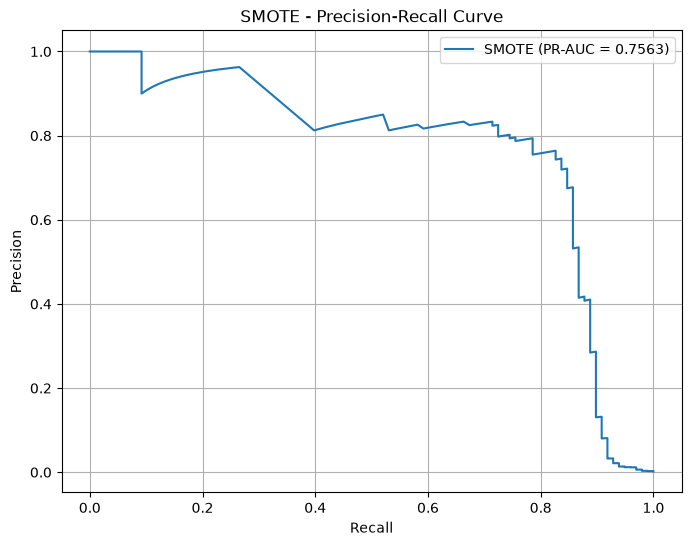

In [17]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"SMOTE (PR-AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SMOTE - Precision-Recall Curve")

plt.legend()
plt.grid()

plt.show()